In [15]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve,
                             precision_recall_curve)
print("All libraries imported successfully!");

All libraries imported successfully!


In [16]:
url = "https://raw.githubusercontent.com/Roopa-Analytics/CHD-risk-Prediction/main/framingham.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4240, 16)


In [17]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [18]:
print(df.columns.tolist())

['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset information:")
df.info()

In [20]:
missing = pd.DataFrame({
    "Missing count": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(1)
})

print(missing)

                 Missing count  Missing (%)
male                         0          0.0
age                          0          0.0
education                  105          2.5
currentSmoker                0          0.0
cigsPerDay                  29          0.7
BPMeds                      53          1.2
prevalentStroke              0          0.0
prevalentHyp                 0          0.0
diabetes                     0          0.0
totChol                     50          1.2
sysBP                        0          0.0
diaBP                        0          0.0
BMI                         19          0.4
heartRate                    1          0.0
glucose                    388          9.2
TenYearCHD                   0          0.0


In [21]:
df = df.drop(columns=["education"])

print("Education column removed.")
print(df.columns.tolist())

Education column removed.
['male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
print(df["TenYearCHD"].value_counts())

print("\nPercentage:")
print(df["TenYearCHD"].value_counts(normalize=True) * 100)

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

Percentage:
TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64


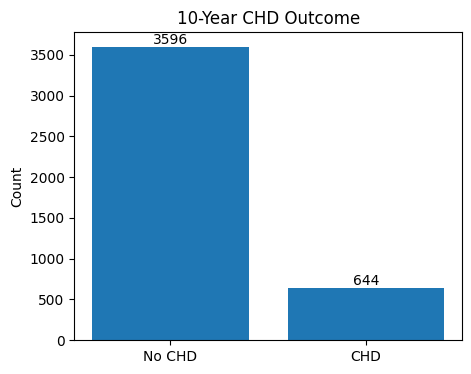

In [24]:
counts = df["TenYearCHD"].value_counts().sort_index()

plt.figure(figsize=(5, 4))

plt.bar(
    ["No CHD", "CHD"],
    counts.values
)

for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.ylabel("Count")
plt.title("10-Year CHD Outcome")

plt.show()

In [25]:
cont_cols = [
    "age",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

rows = []

for col in cont_cols:
    values = df[col].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_out = ((values < lower) | (values > upper)).sum()

    rows.append([
        col,
        n_out,
        round(100 * n_out / len(values), 1)
    ])

outliers = pd.DataFrame(
    rows,
    columns=["Feature", "Outlier count", "Outlier (%)"]
)

outliers

,Feature,Outlier count,Outlier (%)
0,age,0,0.0
1,totChol,56,1.3
2,sysBP,126,3.0
3,diaBP,77,1.8
4,BMI,97,2.3
5,heartRate,76,1.8
6,glucose,188,4.9


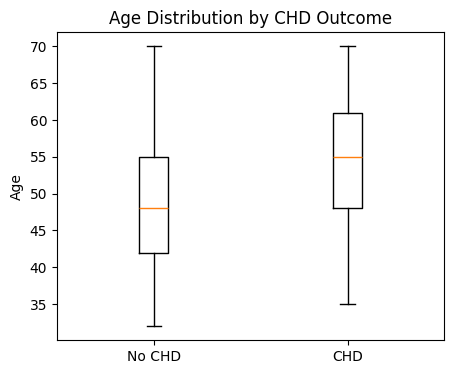

In [26]:
plt.figure(figsize=(5, 4))

plt.boxplot([
    df.loc[df.TenYearCHD == 0, "age"].dropna(),
    df.loc[df.TenYearCHD == 1, "age"].dropna()
])

plt.xticks([1, 2], ["No CHD", "CHD"])
plt.ylabel("Age")
plt.title("Age Distribution by CHD Outcome")

plt.show()

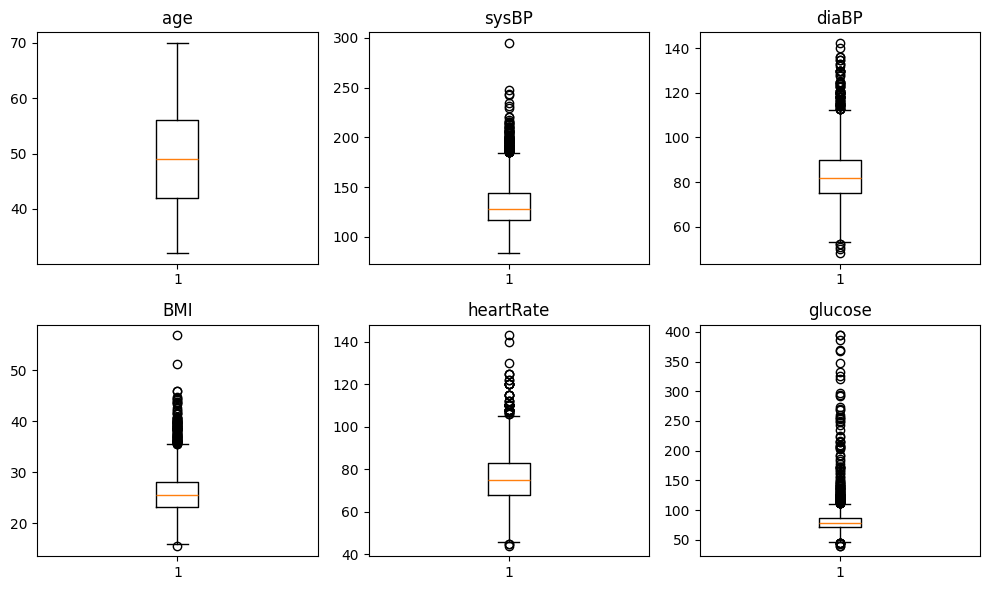

In [27]:
box_cols = [
    "age",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax, col in zip(axes.ravel(), box_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [28]:
#PART 1 — PREPROCESSING
feature_cols = [
    "male",
    "age",
    "currentSmoker",
    "cigsPerDay",
    "BPMeds",
    "prevalentStroke",
    "prevalentHyp",
    "diabetes",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

X = df[feature_cols]
y = df["TenYearCHD"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4240, 14)
y shape: (4240,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training data: (3180, 14)
Testing data: (1060, 14)

Training target:
TenYearCHD
0    2697
1     483
Name: count, dtype: int64

Testing target:
TenYearCHD
0    899
1    161
Name: count, dtype: int64


In [30]:
X_train = X_train.copy()
X_test = X_test.copy()

num_cols = [
    "cigsPerDay",
    "totChol",
    "BMI",
    "heartRate",
    "glucose"
]

for col in num_cols:
    med = X_train[col].median()

    X_train[col] = X_train[col].fillna(med)
    X_test[col] = X_test[col].fillna(med)

bp_mode = X_train["BPMeds"].mode()[0]

X_train["BPMeds"] = X_train["BPMeds"].fillna(bp_mode)
X_test["BPMeds"] = X_test["BPMeds"].fillna(bp_mode)

print(
    "Missing values in training data:",
    X_train.isnull().sum().sum()
)

print(
    "Missing values in testing data:",
    X_test.isnull().sum().sum()
)

Missing values in training data: 0
Missing values in testing data: 0


In [31]:
# helper: all metrics + confusion matrix counts for one model
#PART 2 — BASELINE MODELS
def get_metrics(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Model": name,
        "Threshold": round(float(threshold), 3),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }

In [32]:
def plot_confusion_matrices(prob_dict, thresholds, filename, title):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    for ax, (name, prob) in zip(axes, prob_dict.items()):
        pred = (prob >= thresholds[name]).astype(int)
        ConfusionMatrixDisplay.from_predictions(
            y_test, pred, display_labels=['No CHD', 'CHD'],
            cmap='Blues', colorbar=False, ax=ax, values_format='d')
        ax.set_title(f"{name} (threshold={thresholds[name]:.2f})", fontsize=9)
    fig.suptitle(title)
    savefig(filename)

In [33]:
def plot_confusion_matrices(prob_dict, thresholds, filename, title):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    for ax, (name, prob) in zip(axes, prob_dict.items()):
        pred = (prob >= thresholds[name]).astype(int)
        ConfusionMatrixDisplay.from_predictions(
            y_test, pred, display_labels=['No CHD', 'CHD'],
            cmap='Blues', colorbar=False, ax=ax, values_format='d')
        ax.set_title(f"{name} (threshold={thresholds[name]:.2f})", fontsize=9)
    fig.suptitle(title)
    savefig(filename)

In [34]:
# ---------------- PART 2: BASELINE MODELS (paper setup) ----------------
# Logistic Regression needs scaled features, tree models do not
lr_base = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

In [35]:
rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=42, class_weight=None
)

In [36]:
xgb_base = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='logloss', random_state=42
)

In [37]:
baseline_models = {"Logistic": lr_base, "RandomForest": rf_base, "XGBoost": xgb_base}

In [38]:
base_probs, base_rows = {}, []
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    base_probs[name] = prob
    base_rows.append(get_metrics(name, y_test, prob, 0.5))

base_df = pd.DataFrame(base_rows)
print("\nBASELINE (threshold 0.5)")
print(base_df.round(4).to_string(index=False))
base_df.to_csv(os.path.join(RES_DIR, "results_baseline.csv"), index=False)


BASELINE (threshold 0.5)
       Model  Threshold  Accuracy  Precision  Recall     F1    AUC  TN  FP  FN  TP
    Logistic        0.5    0.8453     0.4286  0.0559 0.0989 0.7044 887  12 152   9
RandomForest        0.5    0.8481     0.5000  0.0683 0.1202 0.6652 888  11 150  11
     XGBoost        0.5    0.8443     0.4474  0.1056 0.1709 0.6730 878  21 144  17


In [39]:
plot_confusion_matrices(base_probs, {k: 0.5 for k in base_probs},
                        "cm_baseline.png", "Baseline models (threshold 0.5)")

In [40]:
#PART 3 — IMPROVED MODELS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos

In [42]:
lr_imp = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight='balanced'))
])

In [43]:
rf_imp = RandomForestClassifier(class_weight='balanced_subsample',
                                random_state=42, n_jobs=-1)

In [44]:
xgb_imp = XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                        scale_pos_weight=spw, random_state=42)

In [45]:
searches = {
    "Logistic": (lr_imp, {"lr__C": [0.01, 0.1, 1, 10]}, 4),
    "RandomForest": (rf_imp, {"n_estimators": [200, 300, 500],
                              "max_depth": [4, 6, 8, None],
                              "min_samples_leaf": [1, 5, 10, 20]}, 15),
    "XGBoost": (xgb_imp, {"n_estimators": [100, 200, 300],
                          "max_depth": [2, 3, 4],
                          "learning_rate": [0.01, 0.05, 0.1],
                          "subsample": [0.7, 0.85, 1.0],
                          "colsample_bytree": [0.7, 0.85, 1.0]}, 15),
}

In [46]:
def best_threshold(model, X_tr, y_tr):
    oof = cross_val_predict(model, X_tr, y_tr, cv=cv, method="predict_proba")[:, 1]
    p, r, t = precision_recall_curve(y_tr, oof)
    f1_scores = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-12)
    return float(t[np.argmax(f1_scores)])

In [47]:
# Hyper tunning
imp_probs, imp_thr, best_models, imp_rows = {}, {}, {}, []
for name, (model, grid, n_iter) in searches.items():
    print(f"\nTuning {name} ...")
    search = RandomizedSearchCV(model, grid, n_iter=n_iter, cv=cv,
                                scoring="average_precision",
                                random_state=42, n_jobs=-1)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    thr = best_threshold(best, X_train, y_train)
    prob = best.predict_proba(X_test)[:, 1]

    best_models[name], imp_probs[name], imp_thr[name] = best, prob, thr
    imp_rows.append(get_metrics(name, y_test, prob, thr))
    print("  best params:", search.best_params_, "| threshold:", round(thr, 3))


Tuning Logistic ...
  best params: {'lr__C': 0.01} | threshold: 0.485

Tuning RandomForest ...
  best params: {'n_estimators': 300, 'min_samples_leaf': 10, 'max_depth': None} | threshold: 0.473

Tuning XGBoost ...
  best params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 0.7} | threshold: 0.563


In [49]:
imp_df = pd.DataFrame(imp_rows)
print("\nIMPROVED (tuned threshold)")
print(imp_df.round(4).to_string(index=False))
imp_df.to_csv(os.path.join(RES_DIR, "results_improved.csv"), index=False)


IMPROVED (tuned threshold)
       Model  Threshold  Accuracy  Precision  Recall     F1    AUC  TN  FP  FN  TP
    Logistic      0.485    0.6500     0.2476  0.6398 0.3570 0.7028 586 313  58 103
RandomForest      0.473    0.7358     0.2738  0.4472 0.3396 0.6861 708 191  89  72
     XGBoost      0.563    0.7302     0.2727  0.4658 0.3440 0.6945 699 200  86  75


In [50]:
comp = base_df.set_index("Model")[["Recall", "F1"]].join(
    imp_df.set_index("Model")[["Recall", "F1"]],
    lsuffix=" (baseline)", rsuffix=" (improved)")
print("\nBaseline vs improved\n", comp.round(4))
comp.to_csv(os.path.join(RES_DIR, "baseline_vs_improved.csv"))
comp.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Score")
plt.title("Baseline vs improved (test set)")
plt.xticks(rotation=0)
savefig("baseline_vs_improved.png")


Baseline vs improved
               Recall (baseline)  F1 (baseline)  Recall (improved)  \
Model                                                               
Logistic                 0.0559         0.0989             0.6398   
RandomForest             0.0683         0.1202             0.4472   
XGBoost                  0.1056         0.1709             0.4658   

              F1 (improved)  
Model                        
Logistic             0.3570  
RandomForest         0.3396  
XGBoost              0.3440  


In [52]:
plt.figure(figsize=(6, 5))
for name, prob in imp_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for CHD Risk Prediction Models')
plt.legend()
plt.grid(True)
savefig("roc_curves.png")

In [53]:
plt.figure(figsize=(6, 5))
for name, prob in imp_probs.items():
    p, r, _ = precision_recall_curve(y_test, prob)
    plt.plot(r, p, label=name)
plt.axhline(y_test.mean(), color='k', linestyle='--', label='No skill')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True)
savefig("pr_curves.png")

In [54]:
rf_best = best_models["RandomForest"]
importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(7, 5))
plt.bar(range(len(feature_cols)), importances[indices])
plt.xticks(range(len(feature_cols)), np.array(feature_cols)[indices],
           rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importances')
savefig("rf_feature_importance.png")

In [55]:
lr_coef = best_models["Logistic"].named_steps["lr"].coef_[0]
odds = pd.Series(np.exp(lr_coef), index=feature_cols).sort_values()
print("\nLogistic odds ratios (per 1 standard deviation):\n", odds.round(3))
odds.to_csv(os.path.join(RES_DIR, "logistic_odds_ratios.csv"))


Logistic odds ratios (per 1 standard deviation):
 heartRate          0.966
BMI                1.041
currentSmoker      1.047
diabetes           1.052
diaBP              1.054
BPMeds             1.081
prevalentHyp       1.092
prevalentStroke    1.096
glucose            1.123
totChol            1.128
male               1.176
cigsPerDay         1.236
sysBP              1.250
age                1.694
dtype: float64


In [56]:
try:
    import shap
    explainer = shap.TreeExplainer(best_models["XGBoost"])
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, show=False)
    savefig("shap_summary_xgb.png")
    print("SHAP plot saved")
except Exception as e:
    print("SHAP skipped:", e)

SHAP plot saved


In [57]:
print("\nDone. Figures in /figures, tables in /results")


Done. Figures in /figures, tables in /results
